In [1]:
print("hello")

hello


In [ ]:
# %load_ext tensorboard
# %tensorboard --logdir logs/fit


# import subprocess
# subprocess.Popen(['tensorboard', '--logdir', 'logs/fit', '--port', '6006'])

In [2]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt
import numpy as np


In [3]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [4]:
(x_train,y_train),(x_test,y_test)=keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 141s 1us/step


In [5]:
x_train.shape

(50000, 32, 32, 3)

In [8]:
x_train[0][0][0]

array([59, 62, 63], dtype=uint8)

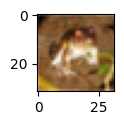

In [21]:
# you can present parts from the image as you can just understand

def plot_sample_parts(index):
    plt.figure(figsize=(10,1))
    plt.imshow(x_train[index][5:9])
    
def plot_sample(index):
    plt.figure(figsize=(10,1))
    plt.imshow(x_train[index]/255)
    
plot_sample(0)

In [18]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]


In [20]:
y_train[3][0]

np.uint8(4)

In [22]:
x_train_scaled=x_train/255
x_test_scaled=x_test/255

In [25]:
y_train_categorical=keras.utils.to_categorical(
    y_train,num_classes=10,
)
y_train_categorical[0:4]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]])

In [26]:
y_test_categorical=keras.utils.to_categorical(
    y_test,num_classes=10
)


In [38]:
model=keras.Sequential(
    [
        keras.layers.Flatten(input_shape=(32,32,3)),
        
        keras.layers.Dense(3000,activation="relu"),
        keras.layers.Dense(1000,activation="relu"),
        
        
        keras.layers.Dense(10,activation="sigmoid")
    ]
)

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.fit(x_train_scaled,y_train_categorical,epochs=50)

Epoch 1/50
 120/1563 ━━━━━━━━━━━━━━━━━━━━ 4:29 187ms/step - accuracy: 0.1411 - loss: 4.3326

KeyboardInterrupt: 